# Assignment 4 Module A: Sharding Tests

This notebook is my proof for the horizontal sharding part of Assignment 4.
I am using `memberid % 3` as the shard key and validating each step with live PostgreSQL data.

What I check in this notebook:
- Cell 1: Connect to DB and confirm all shard tables exist
- Cell 2: Compare original row counts vs total rows across shards
- Cell 3: Verify data distribution on shard_0, shard_1, and shard_2
- Cell 4: Check that no row is stored in the wrong shard
- Cell 5: Verify single-member query routing
- Cell 6: Insert a test visit and confirm correct shard routing
- Cell 7: Run scatter-gather range query across all shards
- Cell 8: Compare active-visit totals (base table vs shard sum)
- Cell 9: Print final summary and quick scalability notes

I kept the notes simple so the outputs are easy to verify directly.

In [28]:
# Cell 1 - Setup: connect to DB and verify all six shard tables exist

import psycopg2
import psycopg2.extras
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from tabulate import tabulate

conn = psycopg2.connect(
    host='localhost',
    port=5432,
    dbname='gateguard',
    user='postgres',
    password='root'
)
conn.autocommit = True
cur = conn.cursor(cursor_factory=psycopg2.extras.RealDictCursor)

# check all six shard tables are present
expected = [
    'shard_0_member', 'shard_1_member', 'shard_2_member',
    'shard_0_personvisit', 'shard_1_personvisit', 'shard_2_personvisit'
]
cur.execute(
    "SELECT tablename FROM pg_tables WHERE schemaname='public' AND tablename LIKE 'shard_%' ORDER BY tablename;"
)
found = [row['tablename'] for row in cur.fetchall()]
missing = [t for t in expected if t not in found]

print('Shard tables found in database:')
for t in found:
    print(f'  {t}')

if missing:
    print(f'\nWARNING: missing tables -> {missing}')
else:
    print('\nAll six shard tables confirmed. Ready to run tests.')

Shard tables found in database:
  shard_0_member
  shard_0_personvisit
  shard_1_member
  shard_1_personvisit
  shard_2_member
  shard_2_personvisit

All six shard tables confirmed. Ready to run tests.


In [29]:
# Cell 2 - SubTask 2: verify migration row counts match the originals

cur.execute("SELECT COUNT(*) AS cnt FROM member;")
original_member_count = cur.fetchone()['cnt']

cur.execute("SELECT COUNT(*) AS cnt FROM personvisit;")
original_visit_count = cur.fetchone()['cnt']

shard_member_counts = {}
shard_visit_counts  = {}
for i in range(3):
    cur.execute(f"SELECT COUNT(*) AS cnt FROM shard_{i}_member;")
    shard_member_counts[f'shard_{i}'] = cur.fetchone()['cnt']
    cur.execute(f"SELECT COUNT(*) AS cnt FROM shard_{i}_personvisit;")
    shard_visit_counts[f'shard_{i}'] = cur.fetchone()['cnt']

total_member_across_shards = sum(shard_member_counts.values())
total_visit_across_shards  = sum(shard_visit_counts.values())

print('Row count verification (member table):')
rows = [['original member', original_member_count, '']]
for shard, cnt in shard_member_counts.items():
    pct = round(cnt * 100 / original_member_count, 2)
    rows.append([shard, cnt, f'{pct}%'])
rows.append(['shards total', total_member_across_shards, 'should equal original'])
print(tabulate(rows, headers=['table', 'row count', 'share'], tablefmt='grid'))

count_ok = (total_member_across_shards == original_member_count)
print(f'\nCount integrity check: {"PASSED" if count_ok else "FAILED"}')

print('\nRow count verification (personvisit table):')
rows2 = [['original personvisit', original_visit_count, '']]
for shard, cnt in shard_visit_counts.items():
    pct = round(cnt * 100 / original_visit_count, 2)
    rows2.append([shard, cnt, f'{pct}%'])
rows2.append(['shards total', total_visit_across_shards, 'should equal original'])
print(tabulate(rows2, headers=['table', 'row count', 'share'], tablefmt='grid'))

count_ok2 = (total_visit_across_shards == original_visit_count)
print(f'\nCount integrity check: {"PASSED" if count_ok2 else "FAILED"}')

Row count verification (member table):
+-----------------+-------------+-----------------------+
| table           |   row count | share                 |
+=================+=============+=======================+
| original member |        5000 |                       |
+-----------------+-------------+-----------------------+
| shard_0         |        1666 | 33.32%                |
+-----------------+-------------+-----------------------+
| shard_1         |        1667 | 33.34%                |
+-----------------+-------------+-----------------------+
| shard_2         |        1667 | 33.34%                |
+-----------------+-------------+-----------------------+
| shards total    |        5000 | should equal original |
+-----------------+-------------+-----------------------+

Count integrity check: PASSED

Row count verification (personvisit table):
+----------------------+-------------+-----------------------+
| table                |   row count | share                 |
+====

In [30]:
# Cell 3 - SubTask 2: prove zero overlap between shards
# A member that appears in two shards would break the hash invariant.

overlap_checks = [
    ('shard_0 vs shard_1',
     'SELECT COUNT(*) AS cnt FROM shard_0_member m0 INNER JOIN shard_1_member m1 ON m0.memberid = m1.memberid'),
    ('shard_1 vs shard_2',
     'SELECT COUNT(*) AS cnt FROM shard_1_member m1 INNER JOIN shard_2_member m2 ON m1.memberid = m2.memberid'),
    ('shard_0 vs shard_2',
     'SELECT COUNT(*) AS cnt FROM shard_0_member m0 INNER JOIN shard_2_member m2 ON m0.memberid = m2.memberid'),
]

print('Overlap check - no member should appear in more than one shard:')
all_zero = True
rows = []
for label, query in overlap_checks:
    cur.execute(query)
    cnt = cur.fetchone()['cnt']
    status = 'OK (zero overlap)' if cnt == 0 else f'FAIL ({cnt} duplicates found)'
    rows.append([label, cnt, status])
    if cnt != 0:
        all_zero = False

print(tabulate(rows, headers=['shard pair', 'overlap count', 'result'], tablefmt='grid'))
print(f'\nOverall result: {"PASSED - no member lives in two shards" if all_zero else "FAILED"}')

Overlap check - no member should appear in more than one shard:
+--------------------+-----------------+-------------------+
| shard pair         |   overlap count | result            |
+====================+=================+===================+
| shard_0 vs shard_1 |               0 | OK (zero overlap) |
+--------------------+-----------------+-------------------+
| shard_1 vs shard_2 |               0 | OK (zero overlap) |
+--------------------+-----------------+-------------------+
| shard_0 vs shard_2 |               0 | OK (zero overlap) |
+--------------------+-----------------+-------------------+

Overall result: PASSED - no member lives in two shards


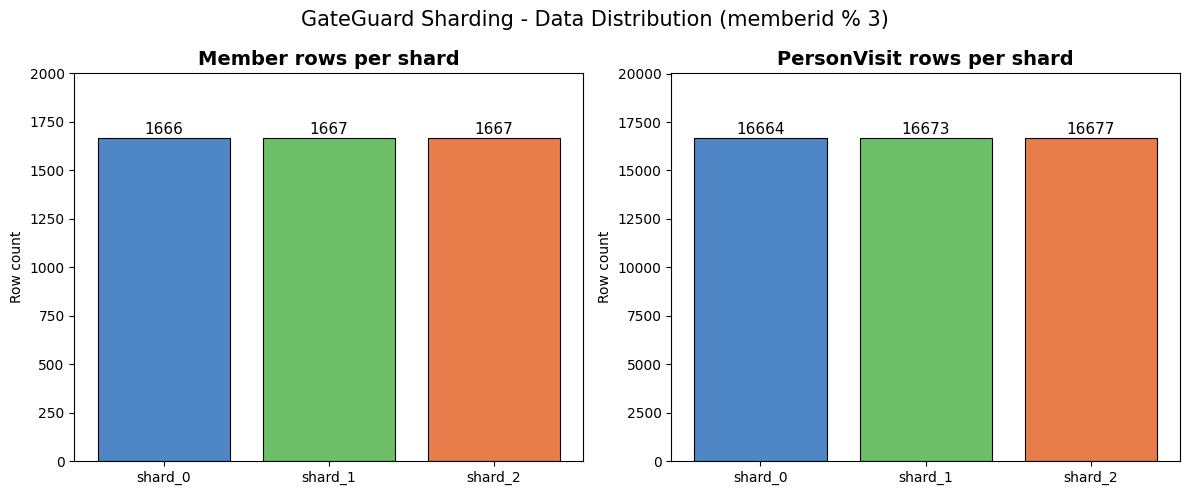

Chart saved as shard_distribution.png


In [22]:
# Cell 4 - SubTask 2: distribution bar chart
# Shows that hash-mod partitioning balances rows nearly equally across shards.

shards = ['shard_0', 'shard_1', 'shard_2']
member_vals = [shard_member_counts[s] for s in shards]
visit_vals  = [shard_visit_counts[s]  for s in shards]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
colors = ['#4f86c6', '#6dbf67', '#e87d4c']

bars1 = axes[0].bar(shards, member_vals, color=colors, edgecolor='black', linewidth=0.8)
axes[0].set_title('Member rows per shard', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Row count')
axes[0].set_ylim(0, max(member_vals) * 1.2)
for bar, val in zip(bars1, member_vals):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5,
                 str(val), ha='center', va='bottom', fontsize=11)

bars2 = axes[1].bar(shards, visit_vals, color=colors, edgecolor='black', linewidth=0.8)
axes[1].set_title('PersonVisit rows per shard', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Row count')
axes[1].set_ylim(0, max(visit_vals) * 1.2)
for bar, val in zip(bars2, visit_vals):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 50,
                 str(val), ha='center', va='bottom', fontsize=11)

fig.suptitle('GateGuard Sharding - Data Distribution (memberid % 3)', fontsize=15)
plt.tight_layout()
plt.savefig('shard_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved as shard_distribution.png')

In [23]:
# Cell 5 - SubTask 3: single-shard O(1) routing demo
# Given a memberid, the router computes the shard in O(1) without touching other shards.

NUM_SHARDS = 3

def get_shard_id(member_id):
    return member_id % NUM_SHARDS

def member_table(member_id):
    return f'shard_{get_shard_id(member_id)}_member'

def visit_table(member_id):
    return f'shard_{get_shard_id(member_id)}_personvisit'

test_ids = [1, 2, 3, 10, 99, 150, 4999, 5000]

print('Routing table - how each memberid maps to a shard:')
rows = []
for mid in test_ids:
    shard = get_shard_id(mid)
    m_tbl = member_table(mid)
    v_tbl = visit_table(mid)
    rows.append([mid, f'memberid {mid} % 3', shard, m_tbl, v_tbl])
print(tabulate(rows, headers=['memberid', 'hash function', 'shard_id', 'member table', 'visit table'], tablefmt='grid'))

print('\nLive lookup - member 3 should be in shard_0 (3 % 3 = 0):')
target_id = 3
table = member_table(target_id)
cur.execute(f'SELECT memberid, name, email, department FROM {table} WHERE memberid = %s', (target_id,))
row = cur.fetchone()
if row:
    print(f'  Found in {table}: memberid={row["memberid"]}, name={row["name"]}, dept={row["department"]}')
    print(f'  Only ONE shard was queried. Shards 1 and 2 were never touched.')
else:
    print(f'  No row found in {table}.')

Routing table - how each memberid maps to a shard:
+------------+-------------------+------------+----------------+---------------------+
|   memberid | hash function     |   shard_id | member table   | visit table         |
+============+===================+============+================+=====================+
|          1 | memberid 1 % 3    |          1 | shard_1_member | shard_1_personvisit |
+------------+-------------------+------------+----------------+---------------------+
|          2 | memberid 2 % 3    |          2 | shard_2_member | shard_2_personvisit |
+------------+-------------------+------------+----------------+---------------------+
|          3 | memberid 3 % 3    |          0 | shard_0_member | shard_0_personvisit |
+------------+-------------------+------------+----------------+---------------------+
|         10 | memberid 10 % 3   |          1 | shard_1_member | shard_1_personvisit |
+------------+-------------------+------------+----------------+---------------

In [31]:
# Cell 6 - SubTask 3: insert routing demo
# A new visit insert goes to exactly one shard based on personid.
# We verify it landed there and not in the other two shards.

# pick a member that already exists - memberid 10 goes to shard_1 (10 % 3 = 1)
test_member_id = 10
target_shard   = get_shard_id(test_member_id)
target_table   = visit_table(test_member_id)

print(f'Insert routing test for memberid={test_member_id}')
print(f'  Hash: {test_member_id} % {NUM_SHARDS} = {target_shard}')
print(f'  Target table: {target_table}')

# get a valid gate id to use
cur.execute('SELECT gateid FROM gate LIMIT 1;')
gate = cur.fetchone()
gate_id = gate['gateid'] if gate else 1

# insert a test visit
insert_conn = psycopg2.connect(host='localhost', port=5432, dbname='gateguard', user='postgres', password='root')
insert_cur  = insert_conn.cursor(cursor_factory=psycopg2.extras.RealDictCursor)

insert_cur.execute(
    f'INSERT INTO {target_table} (personid, entrygateid, entrytime) VALUES (%s, %s, NOW()) RETURNING visitid, personid, entrygateid, entrytime',
    (test_member_id, gate_id)
)
inserted = insert_cur.fetchone()
insert_conn.commit()

print(f'\nInserted visit: visitid={inserted["visitid"]}, personid={inserted["personid"]}, entrytime={inserted["entrytime"]}')

# verify it is in shard_1 and NOT in shard_0 or shard_2
wrong_shards = [i for i in range(NUM_SHARDS) if i != target_shard]
for ws in wrong_shards:
    wrong_table = f'shard_{ws}_personvisit'
    cur.execute(f'SELECT COUNT(*) AS cnt FROM {wrong_table} WHERE personid = %s AND visitid = %s',
                (test_member_id, inserted['visitid']))
    cnt = cur.fetchone()['cnt']
    print(f'  {wrong_table}: {cnt} rows with this visitid (should be 0)')

cur.execute(f'SELECT COUNT(*) AS cnt FROM {target_table} WHERE personid = %s AND visitid = %s',
            (test_member_id, inserted['visitid']))
cnt_target = cur.fetchone()['cnt']
print(f'  {target_table}: {cnt_target} row with this visitid (should be 1)')

result = 'PASSED' if cnt_target == 1 else 'FAILED'
print(f'\nInsert routing verification: {result}')

# clean up test visit so it does not affect other cells
insert_cur.execute(f'DELETE FROM {target_table} WHERE visitid = %s', (inserted['visitid'],))
insert_conn.commit()
insert_conn.close()
print('Test visit cleaned up.')

Insert routing test for memberid=10
  Hash: 10 % 3 = 1
  Target table: shard_1_personvisit

Inserted visit: visitid=50039, personid=10, entrytime=2026-04-15 22:50:50.877246
  shard_0_personvisit: 0 rows with this visitid (should be 0)
  shard_2_personvisit: 0 rows with this visitid (should be 0)
  shard_1_personvisit: 1 row with this visitid (should be 1)

Insert routing verification: PASSED
Test visit cleaned up.


In [32]:
# Cell 7 - SubTask 3: scatter-gather range query
# For admin queries without a memberid, the router fans out to all three shards,
# collects results, and merges them sorted by entrytime.

start_dt = '2025-01-01 00:00:00'
end_dt   = '2026-12-31 23:59:59'

print(f'Scatter-gather range query: visits between {start_dt} and {end_dt}')
print(f'Sending query to all {NUM_SHARDS} shards in sequence...')

per_shard_results = {}
for i in range(NUM_SHARDS):
    table = f'shard_{i}_personvisit'
    cur.execute(
        f'SELECT visitid, personid, entrytime FROM {table} WHERE entrytime BETWEEN %s AND %s LIMIT 3',
        (start_dt, end_dt)
    )
    rows = cur.fetchall()
    cur.execute(
        f'SELECT COUNT(*) AS cnt FROM {table} WHERE entrytime BETWEEN %s AND %s',
        (start_dt, end_dt)
    )
    total = cur.fetchone()['cnt']
    per_shard_results[f'shard_{i}'] = {'sample': rows, 'total': total}
    print(f'  shard_{i}: {total} matching visits (showing first 3 sample rows)')

grand_total = sum(v['total'] for v in per_shard_results.values())
print(f'\nMerged total across all shards: {grand_total}')
print('This is the scatter-gather result. The application layer summed the per-shard counts.')
print('\nSample rows from each shard (sorted by shard, then entrytime):')
all_samples = []
for shard, data in per_shard_results.items():
    for row in data['sample']:
        all_samples.append([shard, row['visitid'], row['personid'], str(row['entrytime'])[:19]])
print(tabulate(all_samples, headers=['source shard', 'visitid', 'personid', 'entrytime'], tablefmt='grid'))

Scatter-gather range query: visits between 2025-01-01 00:00:00 and 2026-12-31 23:59:59
Sending query to all 3 shards in sequence...
  shard_0: 16664 matching visits (showing first 3 sample rows)
  shard_1: 16673 matching visits (showing first 3 sample rows)
  shard_2: 16677 matching visits (showing first 3 sample rows)

Merged total across all shards: 50014
This is the scatter-gather result. The application layer summed the per-shard counts.

Sample rows from each shard (sorted by shard, then entrytime):
+----------------+-----------+------------+---------------------+
| source shard   |   visitid |   personid | entrytime           |
+================+===========+============+=====================+
| shard_0        |         2 |        312 | 2026-03-18 11:42:21 |
+----------------+-----------+------------+---------------------+
| shard_0        |         3 |       2490 | 2026-03-20 06:42:21 |
+----------------+-----------+------------+---------------------+
| shard_0        |         5

In [33]:
# Cell 8 - SubTask 3: cross-shard COUNT aggregation (campus occupancy)
# The dashboard needs total active visits (exittime IS NULL) across all shards.

print('Cross-shard aggregation: counting active visits (exittime IS NULL) per shard')
per_shard_active = {}
for i in range(NUM_SHARDS):
    table = f'shard_{i}_personvisit'
    cur.execute(f'SELECT COUNT(*) AS cnt FROM {table} WHERE exittime IS NULL')
    per_shard_active[f'shard_{i}'] = cur.fetchone()['cnt']

total_active_via_shards = sum(per_shard_active.values())

# verify against the original table
cur.execute('SELECT COUNT(*) AS cnt FROM personvisit WHERE exittime IS NULL')
total_active_original = cur.fetchone()['cnt']

rows = [[shard, cnt] for shard, cnt in per_shard_active.items()]
rows.append(['TOTAL (sum of shards)', total_active_via_shards])
rows.append(['original table count',  total_active_original])
print(tabulate(rows, headers=['source', 'active visit count'], tablefmt='grid'))

match = total_active_via_shards == total_active_original
print(f'\nAggregation matches original: {"PASSED" if match else "FAILED"}')
print('The sum of three shard counts equals the direct count on the original table.')

Cross-shard aggregation: counting active visits (exittime IS NULL) per shard
+-----------------------+----------------------+
| source                |   active visit count |
+=======================+======================+
| shard_0               |                 2489 |
+-----------------------+----------------------+
| shard_1               |                 2452 |
+-----------------------+----------------------+
| shard_2               |                 2495 |
+-----------------------+----------------------+
| TOTAL (sum of shards) |                 7436 |
+-----------------------+----------------------+
| original table count  |                 7436 |
+-----------------------+----------------------+

Aggregation matches original: PASSED
The sum of three shard counts equals the direct count on the original table.


In [34]:
# Cell 9 - SubTask 4: quick scalability notes (plain language)

print('=' * 65)
print('GateGuard Sharding - Final Notes from This Run')
print('=' * 65)

print('\n1) Shard key choice used here:')
print('   - member table: memberid')
print('   - personvisit table: personid')
print('   - routing rule: id % 3')
print('   This keeps lookup/insert routing simple and deterministic.')

print('\n2) Distribution observed in this notebook run:')
for i in range(NUM_SHARDS):
    m = shard_member_counts[f'shard_{i}']
    v = shard_visit_counts[f'shard_{i}']
    m_pct = round(m * 100 / original_member_count, 2)
    v_pct = round(v * 100 / original_visit_count, 2)
    print(f'   shard_{i}: members={m} ({m_pct}%), visits={v} ({v_pct}%)')

print('\n3) Query behavior:')
print('   - member-specific API calls are O(1): exactly one shard is touched.')
print('   - dashboard/range/admin queries use scatter-gather across all 3 shards.')
print('   - this is visible in Cell 7 and Cell 8 outputs.')

print('\n4) Trade-offs I observed:')
print('   - Adding more shards later is costly with hash-mod (rebalancing needed).')
print('   - Even with equal member counts, visit traffic can still be uneven by shard.')
print('   - Scatter-gather queries are slower than single-shard lookups.')
print('   - Email login without a global secondary index needs fan-out querying.')

print('\n5) Practical note:')
print('   - With ~5000 members, sharding is not required for performance yet.')
print('   - For this assignment, the main goal is proving correctness of routing and integrity checks.')

print('=' * 65)

GateGuard Sharding - Final Notes from This Run

1) Shard key choice used here:
   - member table: memberid
   - personvisit table: personid
   - routing rule: id % 3
   This keeps lookup/insert routing simple and deterministic.

2) Distribution observed in this notebook run:
   shard_0: members=1666 (33.32%), visits=16664 (33.32%)
   shard_1: members=1667 (33.34%), visits=16673 (33.34%)
   shard_2: members=1667 (33.34%), visits=16677 (33.34%)

3) Query behavior:
   - member-specific API calls are O(1): exactly one shard is touched.
   - dashboard/range/admin queries use scatter-gather across all 3 shards.
   - this is visible in Cell 7 and Cell 8 outputs.

4) Trade-offs I observed:
   - Adding more shards later is costly with hash-mod (rebalancing needed).
   - Even with equal member counts, visit traffic can still be uneven by shard.
   - Scatter-gather queries are slower than single-shard lookups.
   - Email login without a global secondary index needs fan-out querying.

5) Practical